In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### +__longitude__: Evlerin cografi konumunu belirten boylam bilgisi.<br>+__latitude__: Evlerin cografi konumunu belirten enlem bilgisi.<br>+__housing_median_age__: Bir blok grubundaki evlerin medyan yasi. Evlerin yasini temsil eder.<br>+__households__: Bir blok grubundaki toplam hane halki sayisi.<br>+__median_income__:  Bir blok grubundaki hane halkinin medyan (ortalama) geliri.<br>+__median_house_value__: Bir blok grubundaki evlerin medyan degeri. Bu, sizin tahmin etmeye calistiginiz hedef degiskeninizdir.<br>+__ocean_proximity__:Bir blok grubunun okyanusa ne kadar yakin oldugunu belirten kategorik bir degiskendir

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### Total 20.000 satirlik verinin 200 tanesi eksikse, bu, verinin sadece %1'inin eksik oldugu anlamına gelir (200 / 20000 = 0.01). Bu kadar az bir orandaki eksik veriyi silmek, en hizli ve basit cozumdur.

In [7]:
# Eksik değerleri içeren tüm satırları silin
df.dropna(inplace=True)

# Sildikten sonra kalan satır sayısını kontrol edin
print(f"Eksik degerler silindikten sonra kalan satir sayisi: {len(df)}")

Eksik degerler silindikten sonra kalan satir sayisi: 20433


In [8]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

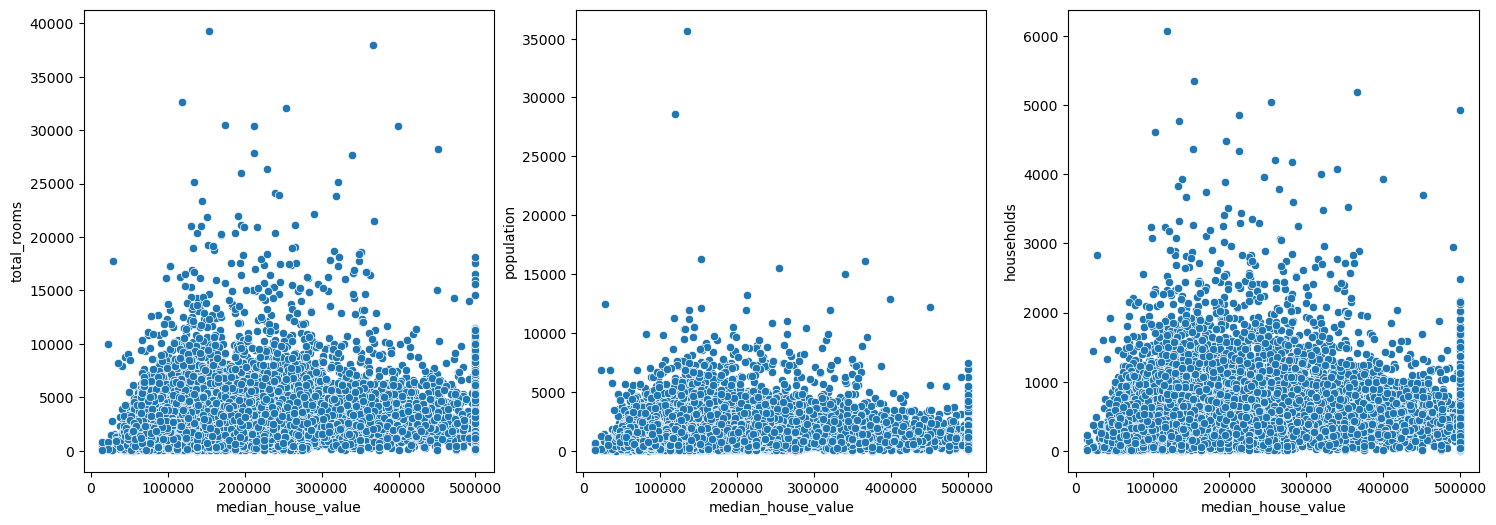

In [9]:
#["longitude","latitude","housing_median_age","longitude","latitude","housing_median_age"] -->bunlarda outlier deger yok
cols = ["total_rooms", "population", "households"]
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
sns.scatterplot(x=df["median_house_value"], y=df["total_rooms"])
plt.subplot(1,3,2)
sns.scatterplot(x=df["median_house_value"], y=df["population"])
plt.subplot(1,3,3)
sns.scatterplot(x=df["median_house_value"], y=df["households"])
plt.show()


In [10]:
# 'ocean_proximity' sütununa One-Hot Encoding uygulama
ocean_proximity_encoded = pd.get_dummies(df['ocean_proximity'], prefix='ocean_proximity')

# Orijinal sütunu DataFrame'den silme
df = df.drop('ocean_proximity', axis=1)

# Yeni oluşturulan One-Hot Encoding sütunlarını DataFrame'e ekleme
df = pd.concat([df, ocean_proximity_encoded], axis=1)

# DataFrame'in son halini kontrol etme
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  \
0                      False                   False                   False   
1   

In [11]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [12]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LinearRegression
lineer_model = LinearRegression()
lineer_model.fit(X_train_scaled, y_train)
y_pred_lineer = lineer_model.predict(X_test_scaled)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("FOR LINEAR;\n")
print("r2 score: ",r2_score(y_test, y_pred_lineer))
print("mean abs error: ",mean_absolute_error(y_test, y_pred_lineer))
print("mean sqrt error: ", mean_squared_error(y_test, y_pred_lineer))

FOR LINEAR;

r2 score:  0.6435297098378023
mean abs error:  50223.044631276854
mean sqrt error:  4850104008.148841


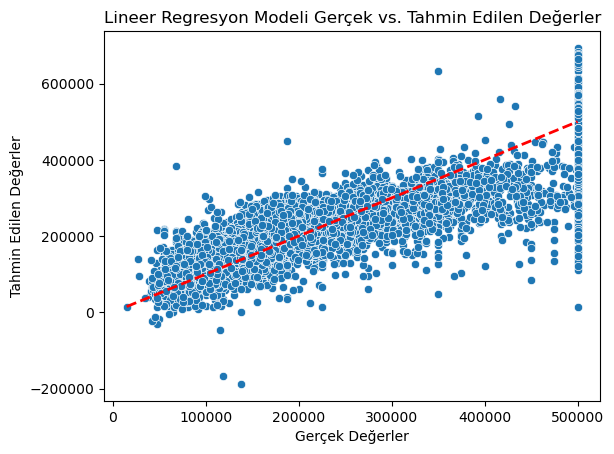

In [14]:

sns.scatterplot(x=y_test, y=y_pred_lineer)


plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)


plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler")
plt.title("Lineer Regresyon Modeli Gerçek vs. Tahmin Edilen Değerler")

plt.show()

In [15]:
import warnings
warnings.filterwarnings("ignore")

## lasso

In [16]:
from sklearn.linear_model import LassoCV
lasso = LassoCV(cv=5)
lasso.fit(X_train_scaled, y_train)
y_tahmin = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_tahmin)
mse = mean_squared_error(y_test, y_tahmin)
r2score = r2_score(y_test, y_tahmin)

print("mean abs error: ", mae)
print("mean sqr error: ", mse)
print("r2score :", r2score)

mean abs error:  50221.20097525404
mean sqr error:  4856560077.869621
r2score : 0.643055205158561


## Ridge 

In [17]:
from sklearn.linear_model import RidgeCV
ridge = RidgeCV(cv=5)
ridge.fit(X_train_scaled, y_train)
y_tahmin = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_tahmin)
mse = mean_squared_error(y_test, y_tahmin)
r2score = r2_score(y_test, y_tahmin)

print("mean abs error: ", mae)
print("mean sqr error: ", mse)
print("r2score :", r2score)

mean abs error:  50223.246364621256
mean sqr error:  4850170013.442513
r2score : 0.6435248586168494


## ElasticNet

In [18]:
from sklearn.linear_model import ElasticNetCV
elastic = ElasticNetCV(cv=5)
elastic.fit(X_train_scaled, y_train)
y_tahmin = elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_tahmin)
mse = mean_squared_error(y_test, y_tahmin)
r2score = r2_score(y_test, y_tahmin)

print("mean abs error: ", mae)
print("mean sqr error: ", mse)
print("r2score :", r2score)
print(":)")

mean abs error:  91281.77922906294
mean sqr error:  13430281314.079695
r2score : 0.012908533724992344
:)


## SVR

mean abs error:  89159.11004521161 

mean sqr error:  14428015367.864662 

r2 score:  -0.06042237774821957 



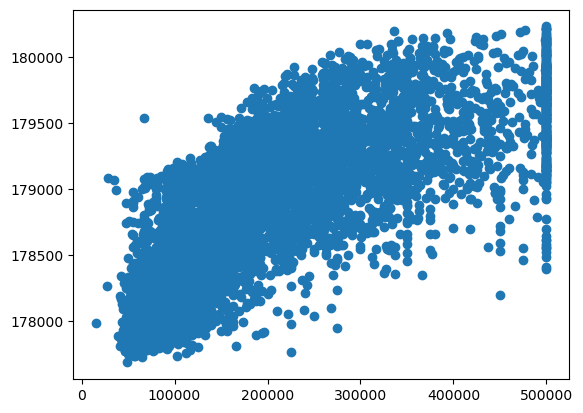

In [19]:
from sklearn.svm import SVR
svr=SVR()
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

mae=mean_absolute_error(y_test, y_pred_svr)
mse=mean_squared_error(y_test, y_pred_svr)
r2score=r2_score(y_test, y_pred_svr)

print("mean abs error: ", mae,"\n")
print("mean sqr error: ", mse,"\n")
print("r2 score: ",r2score, "\n")

plt.scatter(y_test, y_pred_svr)
plt.show()

## HyperParameter Tuning For SVR

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
parametreler={
    "C" : [0.01, 0.1, 1, 10, 100, 1000],
    "kernel" : ["linear", "rbf"], #poly vs de koyabilirz ama cok cok uzun surer hepsini denemesi
    "gamma" : ["scale", "auto"],
}

In [22]:
grid = GridSearchCV(estimator=SVR(), param_grid=parametreler, n_jobs=-1, verbose=3)
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             verbose=3)

In [23]:
print(grid.best_params_)

{'C': 1000, 'gamma': 'scale', 'kernel': 'linear'}


mean abs error:  49256.35967051596 

mean sqr error:  5118222868.728177 

r2 score:  0.6238236565515032 



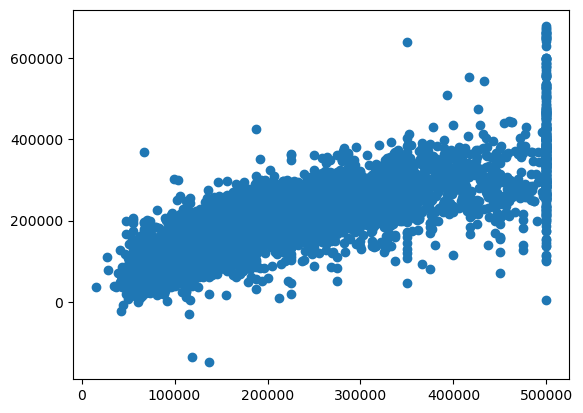

In [24]:
y_pred_svr_tuning = grid.predict(X_test_scaled)

mae=mean_absolute_error(y_test, y_pred_svr_tuning)
mse=mean_squared_error(y_test, y_pred_svr_tuning)
r2score=r2_score(y_test, y_pred_svr_tuning)

print("mean abs error: ", mae,"\n")
print("mean sqr error: ", mse,"\n")
print("r2 score: ",r2score, "\n")

plt.scatter(y_test, y_pred_svr_tuning)
plt.show()

## Decision Tree Regressor

In [25]:
from sklearn.tree import DecisionTreeRegressor

[sklearn/decisionTreeRegressor dokumantasyonu icin tiklayiniz..](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

In [26]:
tree_model = DecisionTreeRegressor()
tree_model.fit(X_train_scaled, y_train)
y_pred_dtree = tree_model.predict(X_test_scaled)

In [27]:
mae=mean_absolute_error(y_test, y_pred_dtree)
mse=mean_squared_error(y_test, y_pred_dtree)
r2score=r2_score(y_test, y_pred_dtree)

print("mean abs error: ", mae,"\n")
print("mean sqr error: ", mse,"\n")
print("r2 score: ",r2score, "\n")

mean abs error:  44470.35089722675 

mean sqr error:  4857370798.833768 

r2 score:  0.6429956192328066 



## Hyperparameter Tuning For DTree Regressor

In [28]:
parametreler_tree={
    "criterion" : ["squared_error", "friedman_mse", "absolute_error", "poisson"],
    "splitter" : ["best" ,"random"],
    "max_depth" : [1,2,3,4,5,6,7,8,9,10 ,None],
    "max_features" : ["log2", "sqrt", None]
}

In [29]:
grid_tree = GridSearchCV(estimator=DecisionTreeRegressor(), param_grid=parametreler_tree, cv=5, scoring="r2", n_jobs=-1)
grid_tree.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None],
                         'max_features': ['log2', 'sqrt', None],
                         'splitter': ['best', 'random']},
             scoring='r2')

In [30]:
print(grid_tree.best_params_)

{'criterion': 'poisson', 'max_depth': 9, 'max_features': None, 'splitter': 'best'}


In [31]:
y_pred_tree_reg = grid.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred_tree_reg)
mse=mean_squared_error(y_test, y_pred_tree_reg)
r2score=r2_score(y_test, y_pred_tree_reg)

print("mean abs error: ", mae,"\n")
print("mean sqr error: ", mse,"\n")
print("r2 score: ",r2score, "\n")

mean abs error:  49256.35967051596 

mean sqr error:  5118222868.728177 

r2 score:  0.6238236565515032 



<Figure size 1500x1000 with 0 Axes>

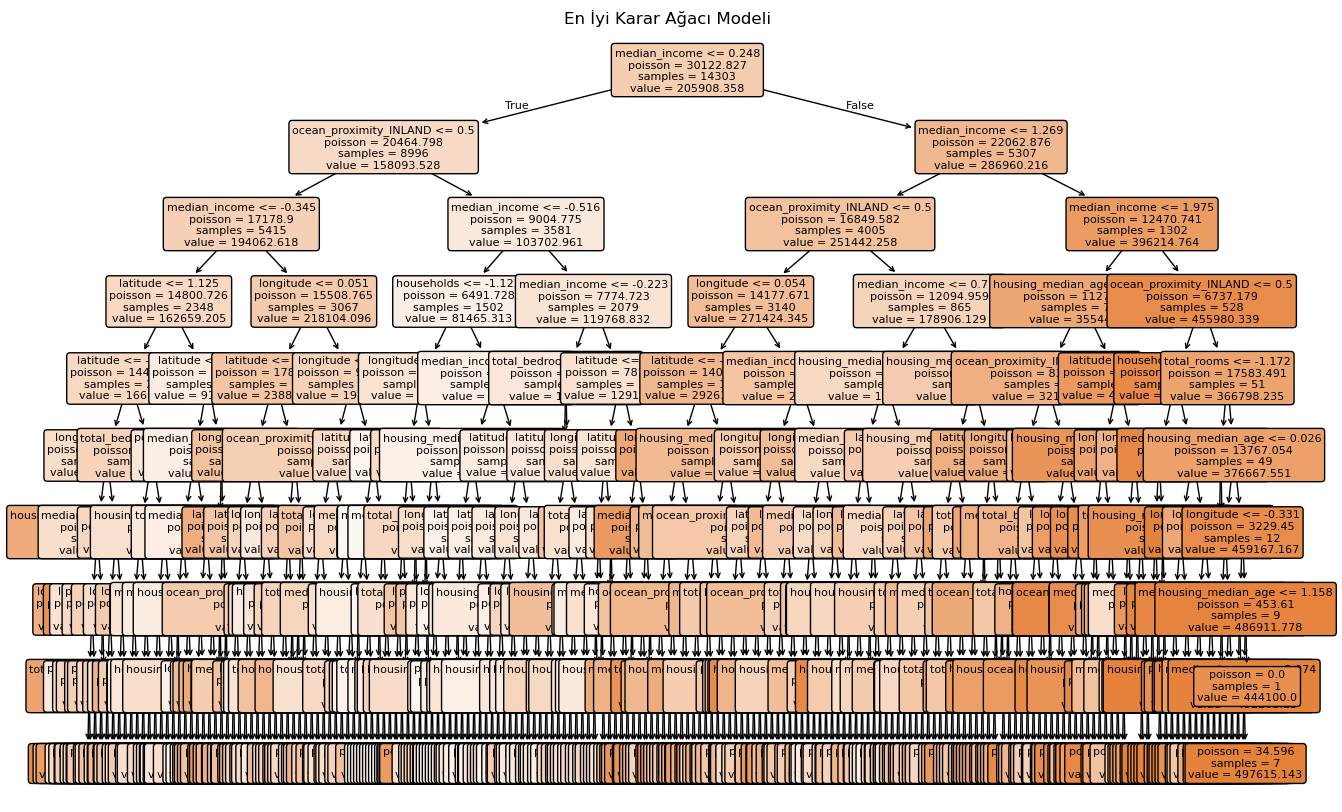

In [33]:
from sklearn import tree
best_tree_model = grid_tree.best_estimator_

plt.figure(figsize=(15, 10))
tree.plot_tree(
    best_tree_model, 
    feature_names=list(X_train.columns), 
    filled=True, 
    rounded=True, 
    fontsize=8
)
plt.title("En İyi Karar Ağacı Modeli")
plt.show()